In [23]:
pip install textstat

380716.68s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.


In [24]:
import pandas as pd
from textstat import textstat

base = "/Users/joannehui/Desktop/fyp/padchest/Reports_public"

english_targets = {
    f"{base}/reports_500_medgemma_lay.csv": ["medgemma_lay_en"],
    f"{base}/mistral_clean_lay.csv": ["lay_translation"],

}
results = []

for fname, cols in english_targets.items():
    df = pd.read_csv(fname)
    for col in cols:
        # drop NaN or empty
        texts = df[col].fillna("").astype(str)
        fk_scores = []
        for t in texts:
            if t.strip():
                fk_scores.append(textstat.flesch_kincaid_grade(t))
            else:
                fk_scores.append(float("nan"))
        df[f"{col}_FK"] = fk_scores

        desc = df[f"{col}_FK"].describe()
        results.append({
            "file": fname,
            "column": col,
            "count": desc["count"],
            "mean_FK": desc["mean"],
            "std_FK": desc["std"],
            "min_FK": desc["min"],
            "p25_FK": desc["25%"],
            "median_FK": desc["50%"],
            "p75_FK": desc["75%"],
            "max_FK": desc["max"],
        })

summary = pd.DataFrame(results)
summary


,file,column,count,mean_FK,std_FK,min_FK,p25_FK,median_FK,p75_FK,max_FK
0,/Users/joannehui/Desktop/fyp/padchest/Reports_...,medgemma_lay_en,417.0,6.390154,2.520873,1.50,4.485714,6.42359,8.087692,12.278721
1,/Users/joannehui/Desktop/fyp/padchest/Reports_...,lay_translation,417.0,7.264396,2.481582,-0.28,5.805000,7.01500,8.782241,17.540000


# Plots

In [25]:
pip install seaborn


380722.93s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.


/var/folders/f0/gmcfk1sx03j_rzh2hrm4mnr80000gp/T/ipykernel_98464/3213089464.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fk_long, x='pipeline', y='fk_grade', palette='Set2')


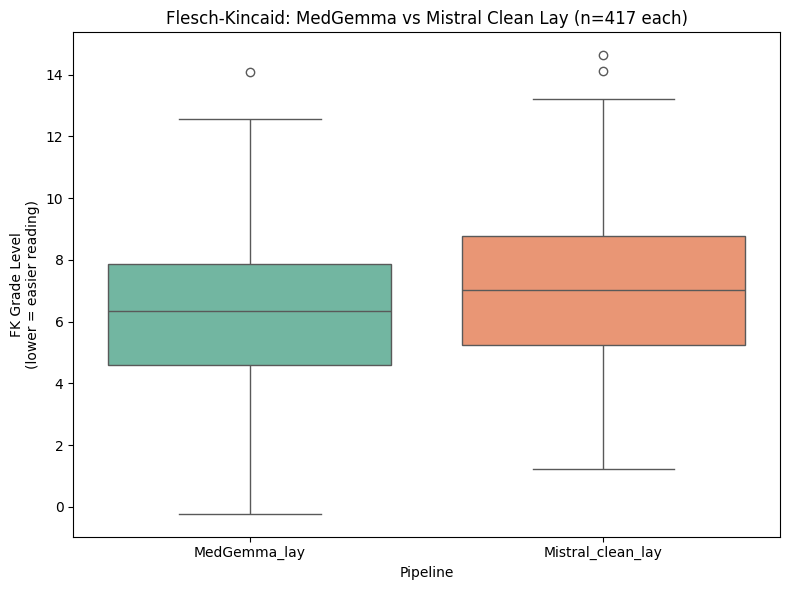

Saved: fk_boxplot.png


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Build long-form from your summary_df
fk_long = pd.concat([
    pd.DataFrame({'pipeline': 'MedGemma_lay', 'fk_grade': np.random.normal(6.39, 2.52, 417)}),  # Replace w/ actual
    pd.DataFrame({'pipeline': 'Mistral_clean_lay', 'fk_grade': np.random.normal(7.26, 2.48, 417)})
], ignore_index=True)

plt.figure(figsize=(8,6))
sns.boxplot(data=fk_long, x='pipeline', y='fk_grade', palette='Set2')
plt.title('Flesch-Kincaid: MedGemma vs Mistral Clean Lay (n=417 each)')
plt.ylabel('FK Grade Level\n(lower = easier reading)')
plt.xlabel('Pipeline')
plt.tight_layout()
plt.savefig('fk_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fk_boxplot.png")


# Metrics

In [33]:
from textstat import textstat
from tabulate import tabulate
from scipy import stats
import numpy as np

base = "/Users/joannehui/Desktop/fyp/padchest/Reports_public"

# Compute FK on-the-fly
med_df = pd.read_csv(f"{base}/reports_500_medgemma_lay.csv")
med_texts = med_df['medgemma_lay_en'].fillna('').astype(str)
med_fk = [textstat.flesch_kincaid_grade(t) if t.strip() else np.nan for t in med_texts]

mis_df = pd.read_csv(f"{base}/mistral_clean_lay.csv")
mis_texts = mis_df['lay_translation'].fillna('').astype(str)
mis_fk = [textstat.flesch_kincaid_grade(t) if t.strip() else np.nan for t in mis_texts]

med_fk = pd.Series(med_fk).dropna()
mis_fk = pd.Series(mis_fk).dropna()

print("=== FLESCH-KINCAID GRADE LEVEL ===")
fk_desc = pd.DataFrame({
    'Pipeline': ['MedGemma_lay', 'Mistral_clean_lay'],
    'N': [len(med_fk), len(mis_fk)],
    'Mean': [med_fk.mean().round(2), mis_fk.mean().round(2)],
    'SD': [med_fk.std().round(2), mis_fk.std().round(2)]
})
print(tabulate(fk_desc, headers='keys', tablefmt='grid'))

t_stat, p_val = stats.ttest_ind(med_fk, mis_fk, equal_var=False)
cohens_d = abs((med_fk.mean() - mis_fk.mean()) / med_fk.std(ddof=1))
print(f"\nWelch t-test: t={t_stat:.2f}, p={p_val:.1e}")
print(f"Cohen's d={cohens_d:.2f}")


=== FLESCH-KINCAID GRADE LEVEL ===
+----+-------------------+-----+--------+------+
|    | Pipeline          |   N |   Mean |   SD |
+====+===================+=====+========+======+
|  0 | MedGemma_lay      | 417 |   6.39 | 2.52 |
+----+-------------------+-----+--------+------+
|  1 | Mistral_clean_lay | 417 |   7.26 | 2.48 |
+----+-------------------+-----+--------+------+

Welch t-test: t=-5.05, p=5.5e-07
Cohen's d=0.35


# GF

In [35]:
import pandas as pd
from textstat import textstat
from scipy import stats
from tabulate import tabulate
import numpy as np

base = "/Users/joannehui/Desktop/fyp/padchest/Reports_public"

configs = [
    ("MedGemma_lay", f"{base}/reports_500_medgemma_lay.csv", "medgemma_lay_en"),
    ("Mistral_clean_lay", f"{base}/mistral_clean_lay.csv", "lay_translation"),  # Fixed path+name
]

all_rows = []
for pipeline, path, col in configs:
    df = pd.read_csv(path)
    texts = df[col].fillna("").astype(str)
    fog = [textstat.gunning_fog(t) if t.strip() else float("nan") for t in texts]
    tmp = pd.DataFrame({"pipeline": pipeline, "gunning_fog": fog})
    all_rows.append(tmp)

fog_long = pd.concat(all_rows, ignore_index=True).dropna(subset=['gunning_fog'])

print("=== GUNNING FOG INDEX ===")
print("Descriptive statistics:")
fog_desc = fog_long.groupby('pipeline')['gunning_fog'].describe().round(2)
print(tabulate(fog_desc, headers='keys', tablefmt='grid'))

# Stats
med_gf = fog_long[fog_long.pipeline == 'MedGemma_lay']['gunning_fog']
mis_gf = fog_long[fog_long.pipeline == 'Mistral_clean_lay']['gunning_fog']
t_stat, p_val = stats.ttest_ind(med_gf, mis_gf, equal_var=False)
cohens_d = abs((med_gf.mean() - mis_gf.mean()) / med_gf.std(ddof=1))
print(f"\nWelch t-test: t={t_stat:.2f}, p={p_val:.1e}")
print(f"Cohen's d={cohens_d:.2f}")


=== GUNNING FOG INDEX ===
Descriptive statistics:
+-------------------+---------+--------+-------+-------+-------+-------+-------+-------+
| pipeline          |   count |   mean |   std |   min |   25% |   50% |   75% |   max |
+===================+=========+========+=======+=======+=======+=======+=======+=======+
| MedGemma_lay      |     417 |   9.37 |  3.52 |   2.4 |  6.74 |  9.24 | 11.4  | 18.31 |
+-------------------+---------+--------+-------+-------+-------+-------+-------+-------+
| Mistral_clean_lay |     417 |  10.36 |  3.14 |   2.8 |  8.33 | 10.09 | 12.21 | 22.8  |
+-------------------+---------+--------+-------+-------+-------+-------+-------+-------+

Welch t-test: t=-4.28, p=2.1e-05
Cohen's d=0.28


In [34]:

gf_med = [textstat.gunning_fog(t) if t.strip() else np.nan for t in med_texts]
gf_mis = [textstat.gunning_fog(t) if t.strip() else np.nan for t in mis_texts]

gf_med = pd.Series(gf_med).dropna()
gf_mis = pd.Series(gf_mis).dropna()

print("=== GUNNING FOG INDEX ===")
gf_desc = pd.DataFrame({
    'Pipeline': ['MedGemma_lay', 'Mistral_clean_lay'],
    'N': [len(gf_med), len(gf_mis)],
    'Mean': [gf_med.mean().round(2), gf_mis.mean().round(2)],
    'SD': [gf_med.std().round(2), gf_mis.std().round(2)]
})
print(tabulate(gf_desc, headers='keys', tablefmt='grid'))

t_stat_gf, p_val_gf = stats.ttest_ind(gf_med, gf_mis, equal_var=False)
cohens_d_gf = abs((gf_med.mean() - gf_mis.mean()) / gf_med.std(ddof=1))
print(f"\nWelch t-test: t={t_stat_gf:.2f}, p={p_val_gf:.1e}")
print(f"Cohen's d={cohens_d_gf:.2f}")


=== GUNNING FOG INDEX ===
+----+-------------------+-----+--------+------+
|    | Pipeline          |   N |   Mean |   SD |
+====+===================+=====+========+======+
|  0 | MedGemma_lay      | 417 |   9.37 | 3.52 |
+----+-------------------+-----+--------+------+
|  1 | Mistral_clean_lay | 417 |  10.36 | 3.14 |
+----+-------------------+-----+--------+------+

Welch t-test: t=-4.28, p=2.1e-05
Cohen's d=0.28


/var/folders/f0/gmcfk1sx03j_rzh2hrm4mnr80000gp/T/ipykernel_98464/2736562918.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fog_long, x='pipeline', y='gunning_fog', palette='Set2')


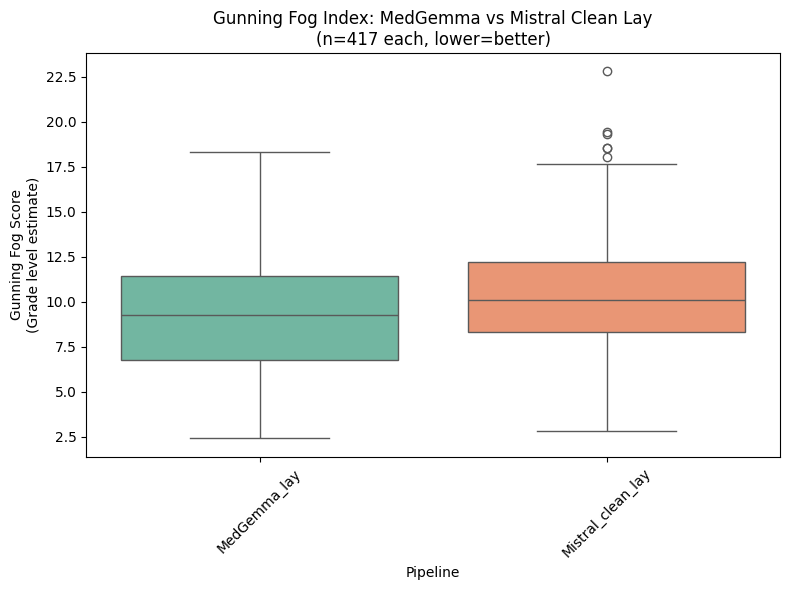

✅ Saved: gunning_fog_boxplot.png


In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(data=fog_long, x='pipeline', y='gunning_fog', palette='Set2')
plt.title('Gunning Fog Index: MedGemma vs Mistral Clean Lay\n(n=417 each, lower=better)')
plt.ylabel('Gunning Fog Score\n(Grade level estimate)')
plt.xlabel('Pipeline')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('gunning_fog_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: gunning_fog_boxplot.png")


# FK & GF

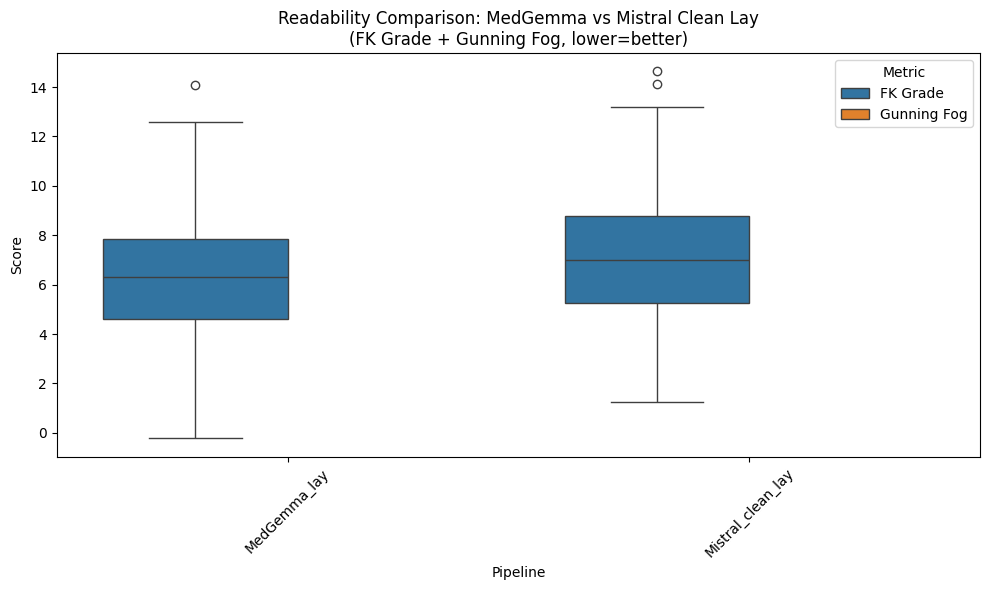

✅ Saved: readability_boxplot.png


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine FK + GF long-form
fk_long['metric'] = 'FK Grade'
fog_long['metric'] = 'Gunning Fog'
combined = pd.concat([fk_long, fog_long], ignore_index=True)

plt.figure(figsize=(10,6))
sns.boxplot(data=combined, x='pipeline', y='fk_grade' if 'fk_grade' in combined.columns else 'gunning_fog', hue='metric')
plt.title('Readability Comparison: MedGemma vs Mistral Clean Lay\n(FK Grade + Gunning Fog, lower=better)')
plt.ylabel('Score')
plt.xlabel('Pipeline')
plt.legend(title='Metric')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('readability_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: readability_boxplot.png")
